In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

print('All libraries imported successfully!')

All libraries imported successfully!


In [2]:
df = pd.read_csv('data.csv', encoding='latin1')

print('Dataset Shape:', df.shape)
print('\nFirst 5 Rows:')
df.head()

Dataset Shape: (541909, 8)

First 5 Rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [3]:
print('Column Names:', df.columns.tolist())
print('\nData Types:')
print(df.dtypes)


Column Names: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Data Types:
InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object


In [4]:
# ── Missing Values ──
print('Missing Values Before Cleaning:')
print(df.isnull().sum())

# Drop rows with missing CustomerID (required for RFM)
df.dropna(subset=['CustomerID'], inplace=True)

# Fill missing Description
df['Description'].fillna('Unknown', inplace=True)

print('\nMissing Values After Cleaning:')
print(df.isnull().sum())

Missing Values Before Cleaning:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Missing Values After Cleaning:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64


In [5]:
# ── Remove Duplicates ──
before = df.shape[0]
df.drop_duplicates(inplace=True)
after = df.shape[0]
print(f'Duplicates removed: {before - after} rows')

Duplicates removed: 5225 rows


In [6]:
# ── Remove Cancelled Orders & Invalid Prices ──
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

print('Clean dataset shape:', df.shape)

Clean dataset shape: (392692, 8)


In [7]:
# ── Feature Engineering ──
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

df['Revenue']    = df['Quantity'] * df['UnitPrice']
df['Month']      = df['InvoiceDate'].dt.month
df['Year']       = df['InvoiceDate'].dt.year
df['DayOfWeek']  = df['InvoiceDate'].dt.day_name()
df['CustomerID'] = df['CustomerID'].astype(int)

print('New columns added: Revenue, Month, Year, DayOfWeek')
df[['InvoiceDate','Revenue','Month','Year','DayOfWeek']].head()

New columns added: Revenue, Month, Year, DayOfWeek


,InvoiceDate,Revenue,Month,Year,DayOfWeek
0,2010-12-01 08:26:00,15.30,12,2010,Wednesday
1,2010-12-01 08:26:00,20.34,12,2010,Wednesday
2,2010-12-01 08:26:00,22.00,12,2010,Wednesday
3,2010-12-01 08:26:00,20.34,12,2010,Wednesday
4,2010-12-01 08:26:00,20.34,12,2010,Wednesday


In [8]:
revenue = df['Revenue'].values
qty     = df['Quantity'].values

print('===== Revenue Statistics =====')
print(f'Mean    : £{np.mean(revenue):.2f}')
print(f'Median  : £{np.median(revenue):.2f}')
print(f'Std Dev : £{np.std(revenue):.2f}')
print(f'Skewness: {pd.Series(revenue).skew():.2f}')
print(f'Min     : £{np.min(revenue):.2f}')
print(f'Max     : £{np.max(revenue):.2f}')

print('\n===== Quantity Statistics =====')
print(f'Mean    : {np.mean(qty):.2f}')
print(f'Median  : {np.median(qty):.2f}')
print(f'Std Dev : {np.std(qty):.2f}')

===== Revenue Statistics =====
Mean    : £22.63
Median  : £12.45
Std Dev : £311.10
Skewness: 448.52
Min     : £0.00
Max     : £168469.60

===== Quantity Statistics =====
Mean    : 13.12
Median  : 6.00
Std Dev : 180.49


In [9]:
df[['Quantity','UnitPrice','Revenue']].describe()

,Quantity,UnitPrice,Revenue
count,392692.000000,392692.000000,392692.000000
mean,13.119702,3.125914,22.631500
std,180.492832,22.241836,311.099224
min,1.000000,0.001000,0.001000
25%,2.000000,1.250000,4.950000
50%,6.000000,1.950000,12.450000
75%,12.000000,3.750000,19.800000
max,80995.000000,8142.750000,168469.600000


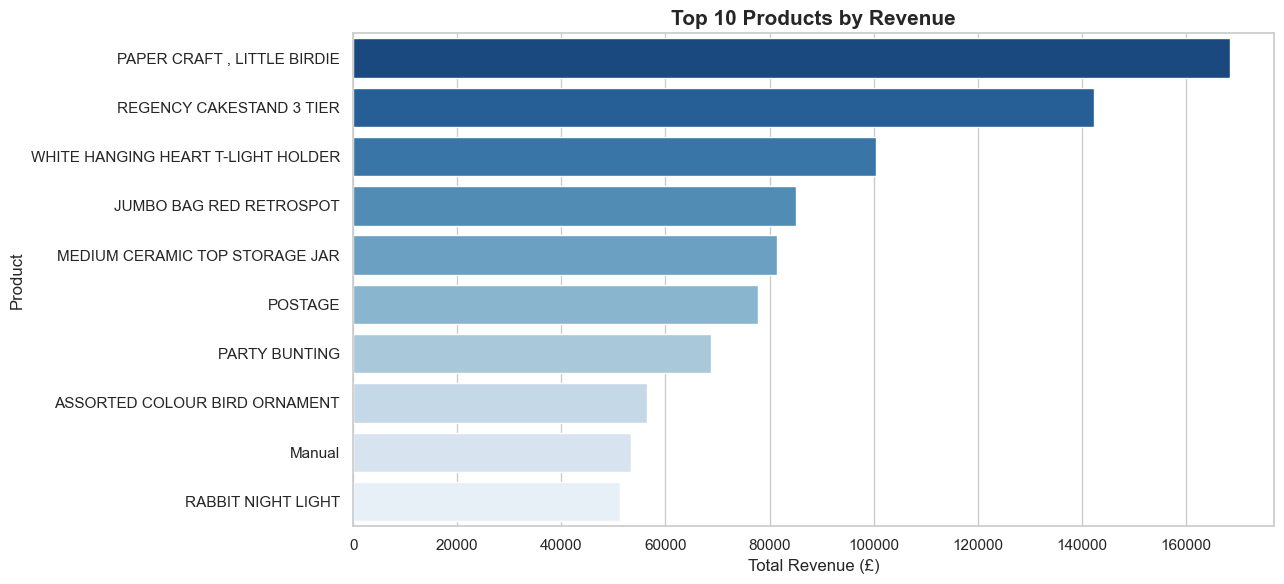

In [10]:
top_products = (
    df.groupby('Description')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(13, 6))
sns.barplot(x=top_products.values, y=top_products.index, palette='Blues_r')
plt.title('Top 10 Products by Revenue', fontsize=15, fontweight='bold')
plt.xlabel('Total Revenue (£)')
plt.ylabel('Product')
plt.tight_layout()
plt.show()

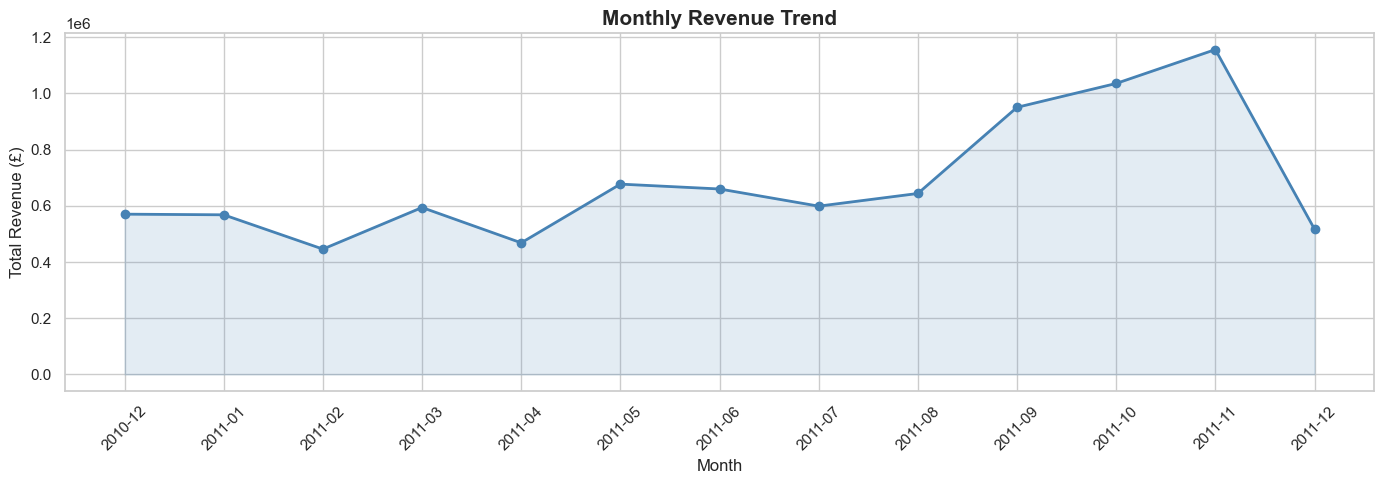

In [11]:
monthly = (
    df.groupby(['Year','Month'])['Revenue']
    .sum()
    .reset_index()
)
monthly['Period'] = monthly['Year'].astype(str) + '-' + monthly['Month'].astype(str).str.zfill(2)
monthly.sort_values('Period', inplace=True)

plt.figure(figsize=(14, 5))
plt.plot(monthly['Period'], monthly['Revenue'], marker='o', color='steelblue', linewidth=2)
plt.fill_between(monthly['Period'], monthly['Revenue'], alpha=0.15, color='steelblue')
plt.title('Monthly Revenue Trend', fontsize=15, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total Revenue (£)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

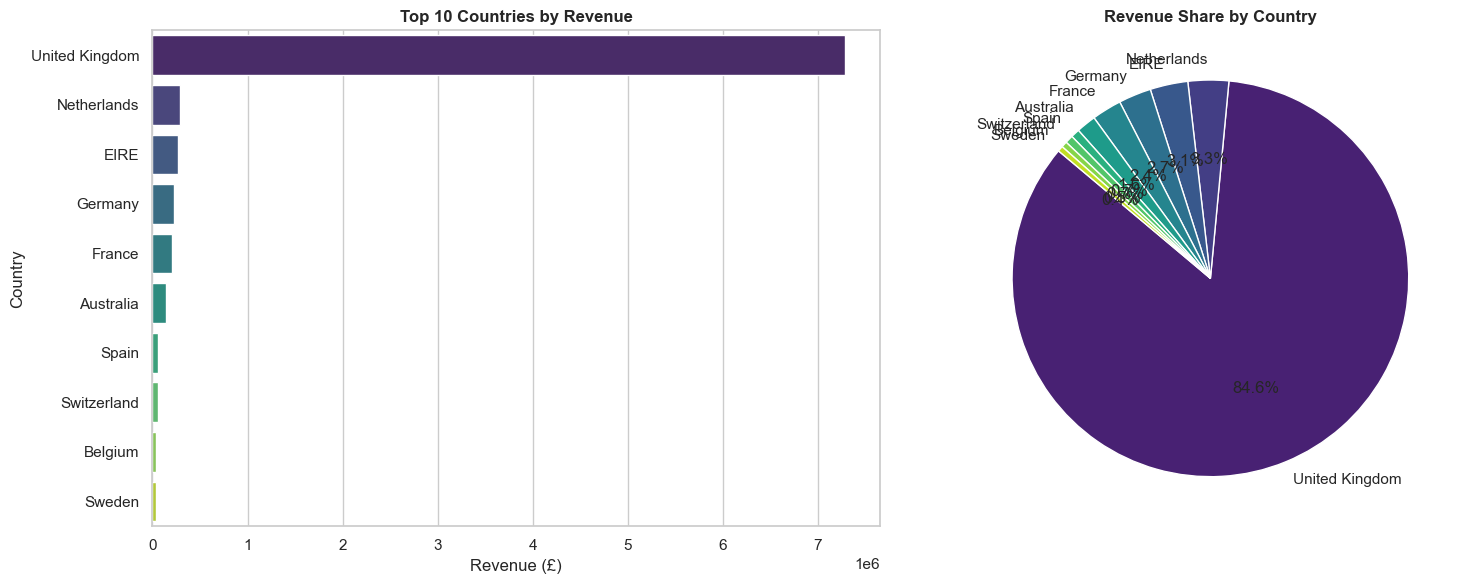

In [12]:
regional = (
    df.groupby('Country')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
sns.barplot(x=regional.values, y=regional.index, palette='viridis', ax=axes[0])
axes[0].set_title('Top 10 Countries by Revenue', fontweight='bold')
axes[0].set_xlabel('Revenue (£)')

# Pie chart
axes[1].pie(regional.values, labels=regional.index, autopct='%1.1f%%',
            startangle=140, colors=sns.color_palette('viridis', len(regional)))
axes[1].set_title('Revenue Share by Country', fontweight='bold')

plt.tight_layout()
plt.show()

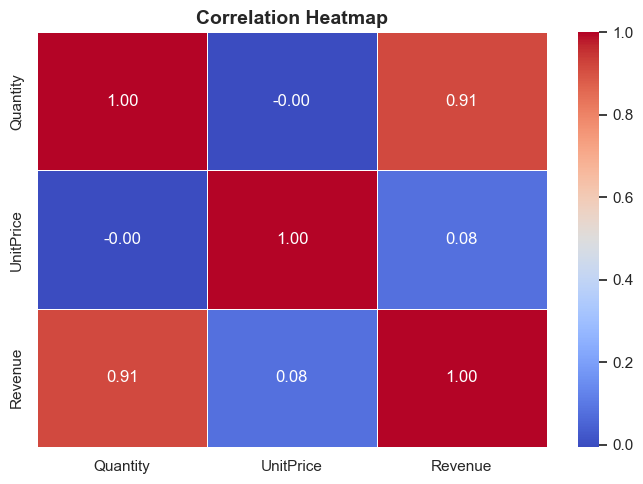

In [15]:
corr = df[['Quantity','UnitPrice','Revenue']].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

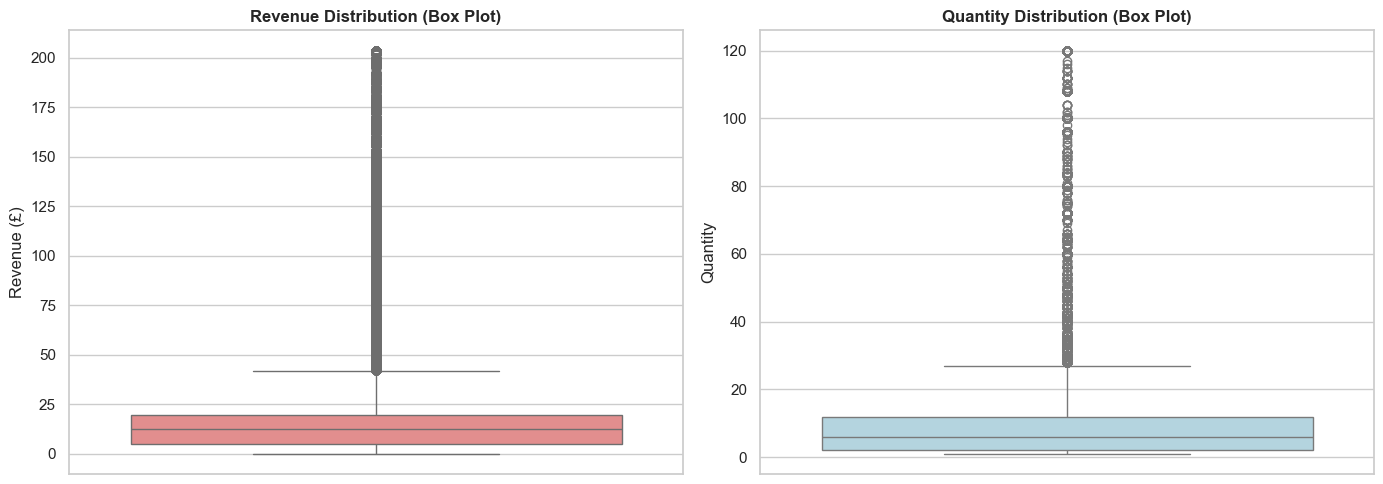

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cap at 99th percentile for visibility
rev_cap = df['Revenue'].clip(upper=df['Revenue'].quantile(0.99))
qty_cap = df['Quantity'].clip(upper=df['Quantity'].quantile(0.99))

sns.boxplot(y=rev_cap, ax=axes[0], color='lightcoral')
axes[0].set_title('Revenue Distribution (Box Plot)', fontweight='bold')
axes[0].set_ylabel('Revenue (£)')

sns.boxplot(y=qty_cap, ax=axes[1], color='lightblue')
axes[1].set_title('Quantity Distribution (Box Plot)', fontweight='bold')
axes[1].set_ylabel('Quantity')

plt.tight_layout()
plt.show()

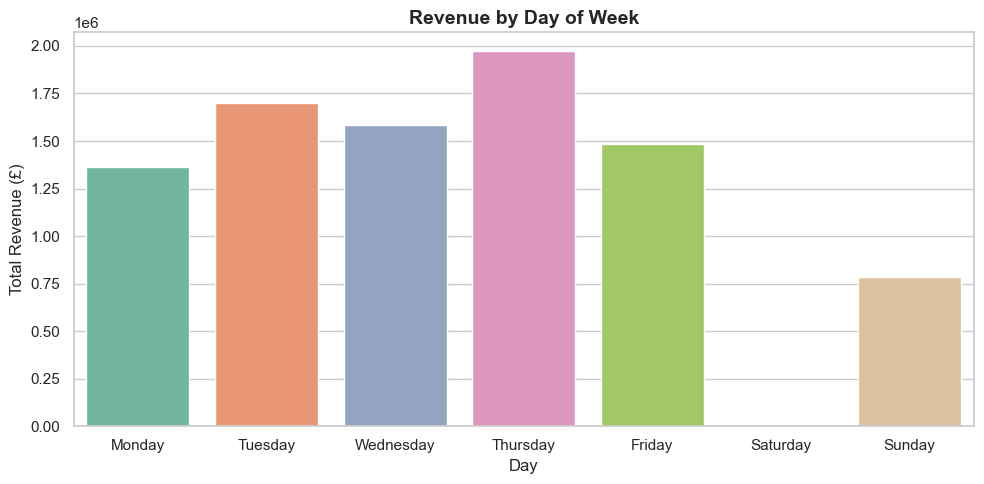

In [17]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_sales = df.groupby('DayOfWeek')['Revenue'].sum().reindex(day_order)

plt.figure(figsize=(10, 5))
sns.barplot(x=day_sales.index, y=day_sales.values, palette='Set2')
plt.title('Revenue by Day of Week', fontsize=14, fontweight='bold')
plt.xlabel('Day')
plt.ylabel('Total Revenue (£)')
plt.tight_layout()
plt.show()

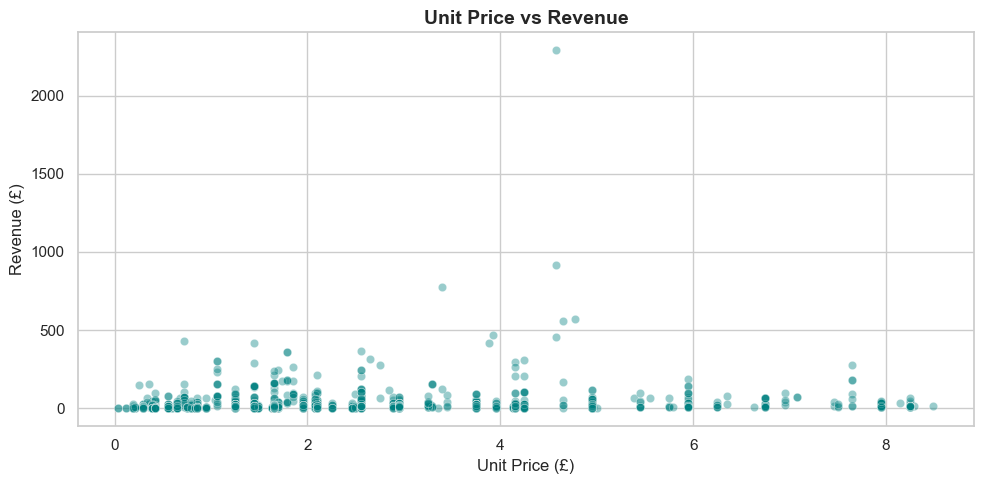

In [18]:
sample = df[df['UnitPrice'] < df['UnitPrice'].quantile(0.95)].sample(3000, random_state=42)

plt.figure(figsize=(10, 5))
sns.scatterplot(data=sample, x='UnitPrice', y='Revenue', alpha=0.4, color='teal')
plt.title('Unit Price vs Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Unit Price (£)')
plt.ylabel('Revenue (£)')
plt.tight_layout()
plt.show()

In [19]:
# ── Calculate RFM ──
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg(
    Recency   = ('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency = ('InvoiceNo',   'nunique'),
    Monetary  = ('Revenue',     'sum')
).reset_index()

print('RFM Table (first 5 rows):')
rfm.head()

RFM Table (first 5 rows):


,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40


In [20]:
# ── Score RFM (1–4 scale) ──
rfm['R_Score'] = pd.qcut(rfm['Recency'],   q=4, labels=[4,3,2,1]).astype(int)
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=4, labels=[1,2,3,4]).astype(int)
rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'),  q=4, labels=[1,2,3,4]).astype(int)

rfm['RFM_Score'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

# ── Segment Customers ──
def segment(score):
    if score >= 10:
        return 'Champions'
    elif score >= 7:
        return 'Loyal'
    elif score >= 5:
        return 'At-Risk'
    else:
        return 'Lost'

rfm['Segment'] = rfm['RFM_Score'].apply(segment)
print(rfm['Segment'].value_counts())
rfm.head()

Segment
Loyal        1276
Champions    1267
At-Risk       989
Lost          806
Name: count, dtype: int64


,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
0,12346,326,1,77183.60,1,1,4,6,At-Risk
1,12347,2,7,4310.00,4,4,4,12,Champions
2,12348,75,4,1797.24,2,3,4,9,Loyal
3,12349,19,1,1757.55,3,1,4,8,Loyal
4,12350,310,1,334.40,1,1,2,4,Lost


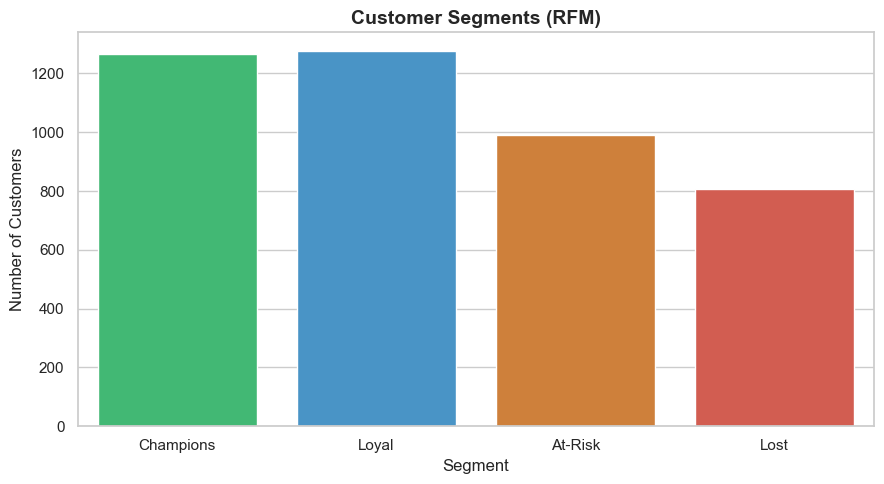

In [21]:
# ── Segment Count Plot ──
plt.figure(figsize=(9, 5))
order = ['Champions','Loyal','At-Risk','Lost']
sns.countplot(data=rfm, x='Segment', order=order,
              palette=['#2ecc71','#3498db','#e67e22','#e74c3c'])
plt.title('Customer Segments (RFM)', fontsize=14, fontweight='bold')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

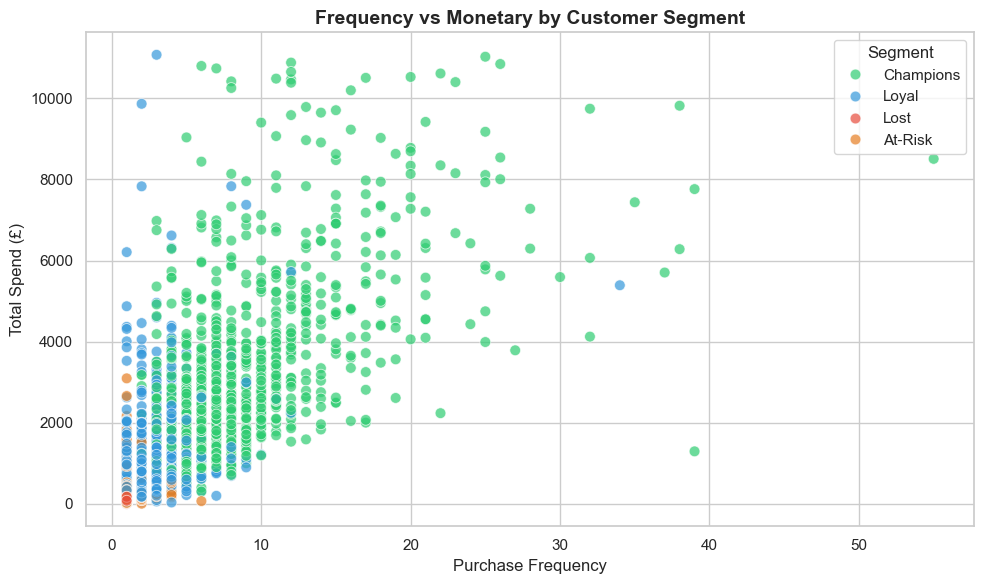

In [22]:
# ── Monetary vs Frequency scatter by Segment ──
plt.figure(figsize=(10, 6))
palette = {'Champions':'#2ecc71','Loyal':'#3498db','At-Risk':'#e67e22','Lost':'#e74c3c'}
sample_rfm = rfm[rfm['Monetary'] < rfm['Monetary'].quantile(0.98)]
sns.scatterplot(data=sample_rfm, x='Frequency', y='Monetary',
                hue='Segment', palette=palette, alpha=0.7, s=60)
plt.title('Frequency vs Monetary by Customer Segment', fontsize=14, fontweight='bold')
plt.xlabel('Purchase Frequency')
plt.ylabel('Total Spend (£)')
plt.legend(title='Segment')
plt.tight_layout()
plt.show()

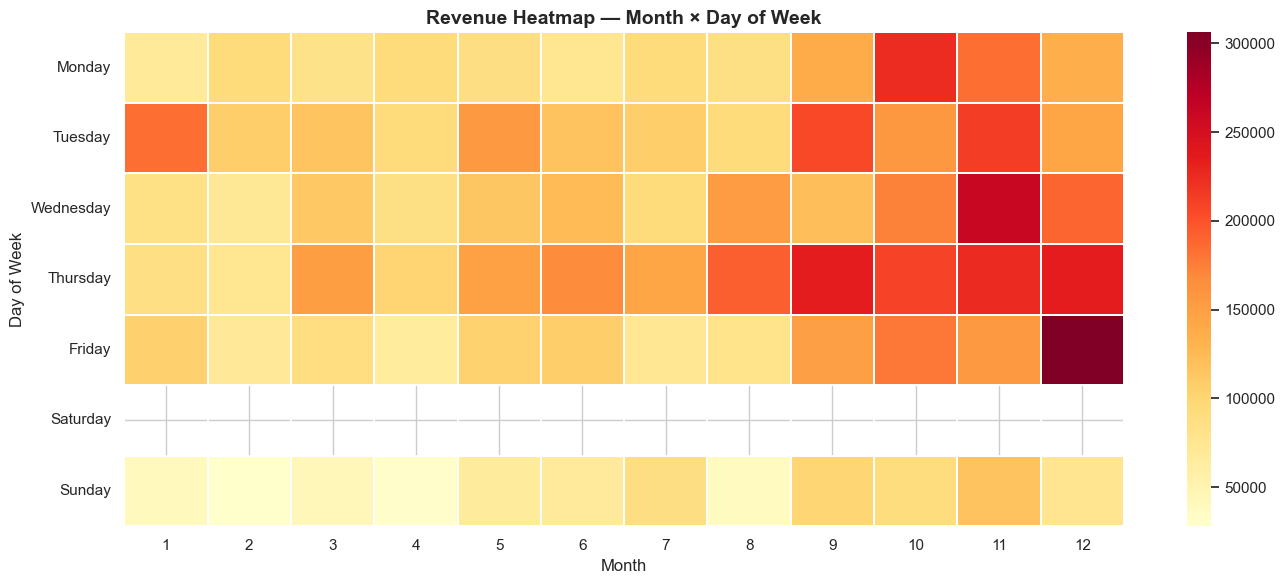

In [23]:
pivot = df.pivot_table(values='Revenue', index='DayOfWeek', columns='Month',
                       aggfunc='sum').reindex(day_order)

plt.figure(figsize=(14, 6))
sns.heatmap(pivot, cmap='YlOrRd', linewidths=0.3, fmt='.0f', annot=False)
plt.title('Revenue Heatmap — Month × Day of Week', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Day of Week')
plt.tight_layout()
plt.show()

In [24]:
print('='*55)
print('         BUSINESS INSIGHTS SUMMARY')
print('='*55)
print(f"Total Transactions   : {len(df):,}")
print(f"Total Revenue        : £{df['Revenue'].sum():,.2f}")
print(f"Unique Customers     : {df['CustomerID'].nunique():,}")
print(f"Unique Products      : {df['Description'].nunique():,}")
print(f"Countries Served     : {df['Country'].nunique()}")
print(f"Top Country          : {df.groupby('Country')['Revenue'].sum().idxmax()}")
print(f"Best Month (Revenue) : {monthly.loc[monthly['Revenue'].idxmax(), 'Period']}")
print(f"Avg Order Value      : £{df['Revenue'].mean():.2f}")
print('-'*55)
print('RFM Segments:')
for seg, cnt in rfm['Segment'].value_counts().items():
    print(f"  {seg:<15}: {cnt} customers")
print('='*55)

         BUSINESS INSIGHTS SUMMARY
Total Transactions   : 392,692
Total Revenue        : £8,887,208.89
Unique Customers     : 4,338
Unique Products      : 3,877
Countries Served     : 37
Top Country          : United Kingdom
Best Month (Revenue) : 2011-11
Avg Order Value      : £22.63
-------------------------------------------------------
RFM Segments:
  Loyal          : 1276 customers
  Champions      : 1267 customers
  At-Risk        : 989 customers
  Lost           : 806 customers
